# Basket Profiling By Final Cluster

This notebook uses `customer_basket.csv` after clustering to understand purchasing behaviour by final K-Means cluster. It does not refit or change the segmentation model.


## Scope

- Read the final cluster assignment from `outputs/customer_clusters.csv`.
- Read basket records from `data/raw/customer_basket.csv`.
- Parse product lists, join baskets to clusters, and create descriptive basket profiles.
- Save only `cluster_basket_profile.csv` and `cluster_top_products.csv`.


## Imports


In [21]:
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../src")

from promotions import (
    add_basket_level_features,
    create_cluster_basket_profile,
    create_cluster_top_products,
    join_baskets_to_clusters,
    validate_customer_clusters,
)

plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
CLUSTER_COLORS = ["#356D8C", "#5C8A72", "#C9822B", "#7C6FA4", "#B4514E"]


## Load Data

Both files are loaded with direct `pd.read_csv` calls. The final cluster file is read only.


In [22]:
customer_basket = pd.read_csv("../data/raw/customer_basket.csv")
customer_clusters = pd.read_csv("../outputs/customer_clusters.csv")

print(f"customer_basket shape: {customer_basket.shape}")
print(f"customer_clusters shape: {customer_clusters.shape}")


customer_basket shape: (100000, 3)
customer_clusters shape: (33038, 2)


## Validate Final Clusters

The cluster assignment must preserve every final customer and contain only `customer_id` and `cluster`.


In [23]:
validate_customer_clusters(customer_clusters)

cluster_validation = pd.DataFrame({
    "check": [
        "cluster columns",
        "cluster rows",
        "unique customer_id",
        "duplicated customer_id",
        "missing cluster values",
        "cluster labels",
    ],
    "value": [
        str(customer_clusters.columns.tolist()),
        len(customer_clusters),
        customer_clusters["customer_id"].nunique(),
        customer_clusters["customer_id"].duplicated().sum(),
        customer_clusters["cluster"].isna().sum(),
        sorted(customer_clusters["cluster"].unique().tolist()),
    ],
})

cluster_validation


,check,value
0,cluster columns,"['customer_id', 'cluster']"
1,cluster rows,33038
2,unique customer_id,33038
3,duplicated customer_id,0
4,missing cluster values,0
5,cluster labels,"[0, 1, 2, 3, 4]"


## Parse Baskets And Join Clusters

Each basket's `list_of_goods` value is parsed into a product list. The join is from basket records to final clusters, so customers without basket records remain in `customer_clusters.csv` and are not removed from the final segmentation output.


In [24]:
baskets = add_basket_level_features(customer_basket)
basket_clusters = join_baskets_to_clusters(baskets, customer_clusters)

basket_customer_ids = set(basket_clusters["customer_id"])
cluster_customer_ids = set(customer_clusters["customer_id"])
customers_without_basket_records = len(cluster_customer_ids - basket_customer_ids)

join_validation = pd.DataFrame({
    "check": [
        "basket rows after join",
        "basket rows missing cluster",
        "unique basket customers",
        "customers without basket records",
        "all basket customers in final clusters",
    ],
    "value": [
        len(basket_clusters),
        basket_clusters["cluster"].isna().sum(),
        basket_clusters["customer_id"].nunique(),
        customers_without_basket_records,
        basket_customer_ids.issubset(cluster_customer_ids),
    ],
})

join_validation


,check,value
0,basket rows after join,100000
1,basket rows missing cluster,0
2,unique basket customers,28127
3,customers without basket records,4911
4,all basket customers in final clusters,True


## Basket-Level Features

The basket-level features are simple descriptive measures: total product count and distinct product count per basket.


In [25]:
baskets[[
    "invoice_id",
    "customer_id",
    "goods_list",
    "basket_size",
    "distinct_products_per_basket",
]].head()


,invoice_id,customer_id,goods_list,basket_size,distinct_products_per_basket
0,3700630,12912,"[chicken, rice, pepper, whole wheat rice, shri...",11,11
1,10242376,22853,"[low fat yogurt, tomatoes, pepper, asparagus, ...",12,12
2,91550,19,"[cake, tomatoes, pancakes, iPad, final fantasy...",7,7
3,3137503,10995,"[cereals, megaman zero, final fantasy XIX, honey]",4,4
4,7165061,27807,"[rice, frozen smoothie, black tea, tea, minecr...",8,8


## Cluster Basket Profile

The profile summarizes basket activity, basket size, product variety, and the share of customers in each final cluster with observed basket records.


In [26]:
cluster_basket_profile = create_cluster_basket_profile(
    basket_clusters,
    customer_clusters,
)
cluster_basket_profile.to_csv("../outputs/cluster_basket_profile.csv", index=False)

cluster_basket_profile


,cluster,number_of_baskets,number_of_customers_with_baskets,average_basket_size,median_basket_size,average_distinct_products_per_basket,total_items_in_baskets,number_of_distinct_products,share_of_cluster_customers_with_baskets
0,0,6987,2198,9.563475,10.0,9.563475,66820,164,0.839252
1,1,50385,15518,9.440627,9.0,9.440627,475666,164,0.844058
2,2,24502,4932,9.517958,10.0,9.517958,233209,164,0.890574
3,3,9362,2982,9.006302,9.0,9.006302,84317,164,0.839527
4,4,8764,2497,9.124030,9.0,9.124030,79963,164,0.848166


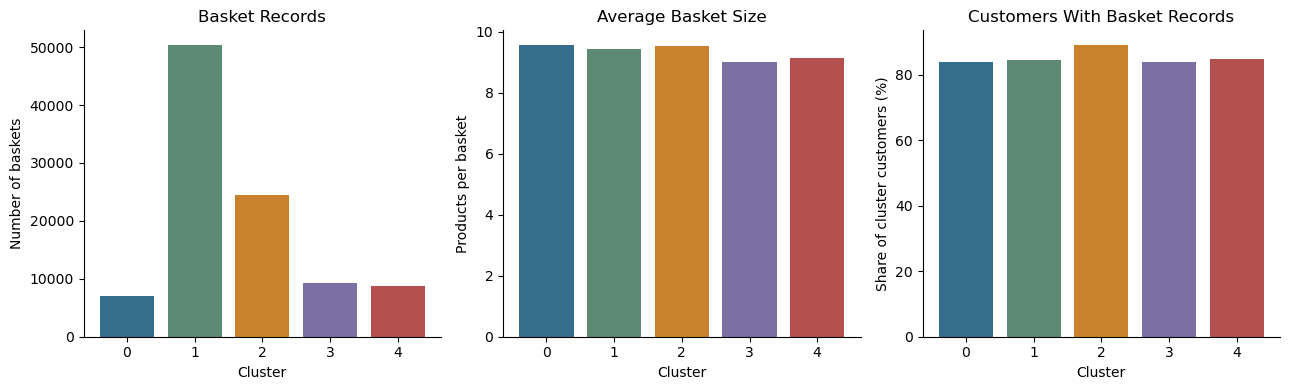

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(
    cluster_basket_profile["cluster"].astype(str),
    cluster_basket_profile["number_of_baskets"],
    color=CLUSTER_COLORS,
)
axes[0].set_title("Basket Records")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Number of baskets")

axes[1].bar(
    cluster_basket_profile["cluster"].astype(str),
    cluster_basket_profile["average_basket_size"],
    color=CLUSTER_COLORS,
)
axes[1].set_title("Average Basket Size")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Products per basket")

axes[2].bar(
    cluster_basket_profile["cluster"].astype(str),
    cluster_basket_profile["share_of_cluster_customers_with_baskets"] * 100,
    color=CLUSTER_COLORS,
)
axes[2].set_title("Customers With Basket Records")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Share of cluster customers (%)")

plt.tight_layout()
plt.show()


## Top Products By Cluster

Top products are counted after exploding the parsed product lists. Product share is calculated within each cluster's observed basket items.


In [28]:
cluster_top_products = create_cluster_top_products(
    basket_clusters,
    top_n=10,
)
cluster_top_products.to_csv("../outputs/cluster_top_products.csv", index=False)

cluster_top_products.head(20)


,cluster,product,product_count,product_share_within_cluster,product_rank
0,0,airpods,1089,0.016298,1
3,0,asparagus,876,0.013110,2
80,0,laptop,632,0.009458,3
12,0,bluetooth headphones,631,0.009443,4
47,0,energy drink,598,0.008949,5
46,0,energy bar,588,0.008800,6
120,0,protein bar,584,0.008740,7
15,0,brownies,573,0.008575,8
18,0,butter,563,0.008426,9
149,0,tomatoes,529,0.007917,10


In [29]:
for cluster in sorted(cluster_top_products["cluster"].unique()):
    display(
        cluster_top_products[cluster_top_products["cluster"] == cluster]
        .head(5)
        .reset_index(drop=True)
    )


,cluster,product,product_count,product_share_within_cluster,product_rank
0,0,airpods,1089,0.016298,1
1,0,asparagus,876,0.013110,2
2,0,laptop,632,0.009458,3
3,0,bluetooth headphones,631,0.009443,4
4,0,energy drink,598,0.008949,5


,cluster,product,product_count,product_share_within_cluster,product_rank
0,1,asparagus,8180,0.017197,1
1,1,airpods,7440,0.015641,2
2,1,tomatoes,4841,0.010177,3
3,1,spinach,4565,0.009597,4
4,1,carrots,4550,0.009566,5


,cluster,product,product_count,product_share_within_cluster,product_rank
0,2,dog food,3663,0.015707,1
1,2,babies food,3441,0.014755,2
2,2,napkins,3104,0.013310,3
3,2,cooking oil,2999,0.012860,4
4,2,cat food,2651,0.011367,5


,cluster,product,product_count,product_share_within_cluster,product_rank
0,3,toothpaste,2926,0.034702,1
1,3,deodorant,2915,0.034572,2
2,3,shampoo,2915,0.034572,3
3,3,shower gel,2881,0.034169,4
4,3,tooth brush,2880,0.034157,5


,cluster,product,product_count,product_share_within_cluster,product_rank
0,4,cereals,3138,0.039243,1
1,4,fresh bread,3128,0.039118,2
2,4,butter,3071,0.038405,3
3,4,eggs,3014,0.037692,4
4,4,bacon,1895,0.023698,5


## Interpretation

- Cluster 1 has the most basket records and total basket items, mainly because it is the largest final segment.
- Cluster 2 has the highest observed basket coverage: about 89% of customers in the cluster have basket records.
- Clusters 0 and 2 have the largest average baskets, both around 9.5 products per basket. Cluster 3 has the smallest average basket size, around 9.0 products per basket.
- Product patterns differ by cluster: clusters 0 and 1 are led by airpods/asparagus, cluster 2 is led by pet/baby and household products, cluster 3 is dominated by hygiene products, and cluster 4 is dominated by breakfast/basic grocery products.
- Caveat: 4,911 final clustered customers do not have basket records, so basket profiling describes observed purchasing behaviour only. Those customers remain in the final `customer_clusters.csv` output.


## Output Check


In [30]:
profile_check = pd.read_csv("../outputs/cluster_basket_profile.csv")
top_products_check = pd.read_csv("../outputs/cluster_top_products.csv")

output_check = pd.DataFrame({
    "output": [
        "cluster_basket_profile.csv",
        "cluster_top_products.csv",
    ],
    "rows": [
        len(profile_check),
        len(top_products_check),
    ],
    "columns": [
        profile_check.shape[1],
        top_products_check.shape[1],
    ],
})

output_check


,output,rows,columns
0,cluster_basket_profile.csv,5,9
1,cluster_top_products.csv,50,5
